# Лабораторная работа: Предварительная обработка данных

## Цель лабораторной работы
Изучение способов предварительной обработки данных для дальнейшего формирования моделей.

## Задание
Выбрать набор данных (датасет), содержащий категориальные признаки и пропуски в данных. Для выполнения следующих пунктов можно использовать несколько различных наборов данных (один для обработки пропусков, другой для категориальных признаков и т.д.).
Для выбранного датасета (датасетов) на основе материалов лекции решить следующие задачи:
1. Обработка пропусков в данных.
2. Кодирование категориальных признаков.
3. Масштабирование данных.

## Требования к отчету
Отчет по лабораторной работе должен содержать:
1. Титульный лист (не включается в данный ipynb).
2. Описание задания.
3. Текст программы.
4. Экранные формы с примерами выполнения программы (в виде графиков и вывода данных).

## 1. Обработка пропусков в данных.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [7]:
# Загружаем датасет
df = sns.load_dataset('penguins')
print('Информация о датасете')
print(df.info())
print('Выведем первые пять строк')
print(df.head())
print('Посмотрим статистику пропусков')
print(df.isnull().sum())

Информация о датасете
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None
Выведем первые пять строк
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN           

Имеем пять признаков с пропусками:
1. bill_length_mm (длина клюва) - числовой признак, будем использовать медиану, т.к. она более устойчива к выбросам. Ко всем остальным числовым признакам также будем применять медиану.
2. bill_depth_mm (глубина клюва) - числовой признак.
3. flipper_length_mm (длина ласт) - числовой признак.
4. body_mass_g (масса тела) - числовой признак.
5. sex (пол) - категориальный признак. Заполним наиболее встречающимся значением (модой).

In [10]:
df_copy = df.copy()

# 1. Обработка числовых признаков, которые заполняем медианой
imputer_bl = SimpleImputer(strategy='median')
df_copy['bill_length_mm'] = imputer_bl.fit_transform(df_copy[['bill_length_mm']]).ravel()
imputer_bd = SimpleImputer(strategy='median')
df_copy['bill_depth_mm'] = imputer_bd.fit_transform(df_copy[['bill_depth_mm']]).ravel()
imputer_fl = SimpleImputer(strategy='median')
df_copy['flipper_length_mm'] = imputer_fl.fit_transform(df_copy[['flipper_length_mm']]).ravel()
imputer_bm = SimpleImputer(strategy='median')
df_copy['body_mass_g'] = imputer_bm.fit_transform(df_copy[['body_mass_g']]).ravel()

# 2. Обработка категориального признака "sex", который заполняем модой
imputer_sex = SimpleImputer(strategy='most_frequent')
df_copy['sex'] = imputer_sex.fit_transform(df_copy[['sex']]).ravel()

print("\nКоличество пропущенных значений после обработки:")
print(df_copy.isnull().sum())

print("\nПервые 5 строк датасета после обработки пропусков:")
print(df_copy.head())


Количество пропущенных значений после обработки:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

Первые 5 строк датасета после обработки пропусков:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen           39.10           18.7              181.0   
1  Adelie  Torgersen           39.50           17.4              186.0   
2  Adelie  Torgersen           40.30           18.0              195.0   
3  Adelie  Torgersen           44.45           17.3              197.0   
4  Adelie  Torgersen           36.70           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3       4050.0    Male  
4       3450.0  Female  


## 2. Кодирование категориальных признаков.

Имеем два категориальных признака: sex и island. Первый закодируем с помощью one-hot encoding, а второй с помощью label encoding

In [16]:
# Создаем копию данных для обработки
df_encoded = df_copy.copy()
print(df_encoded[['sex', 'island']].isnull().sum())

sex       0
island    0
dtype: int64


 One-Hot Encoding для признака 'sex'

In [25]:
# Создаем OneHotEncoder
onehot_encoder = OneHotEncoder(sparse_output=False, dtype=int)

# Применяем к признаку 'sex'
sex_encoded = onehot_encoder.fit_transform(df_copy[["sex"]])

# Получаем названия новых признаков
sex_feature_names = onehot_encoder.get_feature_names_out(["sex"])
print(f"Названия новых признаков: {sex_feature_names}")

# Создаем DataFrame с закодированными признаками
sex_encoded_df = pd.DataFrame(
    sex_encoded, 
    columns=sex_feature_names, 
    index=df_copy.index
)

# Выводим результаты
print(f"\nРезультат One-Hot Encoding:")
print(f"\nПервые 10 строк:")
print(sex_encoded_df.head(10))


Названия новых признаков: ['sex_Female' 'sex_Male']

Результат One-Hot Encoding:

Первые 10 строк:
   sex_Female  sex_Male
0           0         1
1           1         0
2           1         0
3           0         1
4           1         0
5           0         1
6           1         0
7           0         1
8           0         1
9           0         1


In [ ]:
# Создаем LabelEncoder
label_encoder = LabelEncoder()

# Применяем к признаку 'island'
island_encoded = label_encoder.fit_transform(df_copy["island"])

# Выводим соответствие значений
print("Соответствие значений (маппинг):")
for original, encoded in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"  {original:12} -> {encoded}")

# Добавляем закодированный признак в DataFrame
df_copy['island_encoded'] = island_encoded

# Выводим результаты
print(f"\nРезультат Label Encoding:")
print(f"\nПервые 10 строк:")
print(df_copy[["island", 'island_encoded']].head(50))

Соответствие значений (маппинг):
  Biscoe       -> 0
  Dream        -> 1
  Torgersen    -> 2

Результат Label Encoding:

Первые 10 строк:
       island  island_encoded
0   Torgersen               2
1   Torgersen               2
2   Torgersen               2
3   Torgersen               2
4   Torgersen               2
5   Torgersen               2
6   Torgersen               2
7   Torgersen               2
8   Torgersen               2
9   Torgersen               2
10  Torgersen               2
11  Torgersen               2
12  Torgersen               2
13  Torgersen               2
14  Torgersen               2
15  Torgersen               2
16  Torgersen               2
17  Torgersen               2
18  Torgersen               2
19  Torgersen               2
20     Biscoe               0
21     Biscoe               0
22     Biscoe               0
23     Biscoe               0
24     Biscoe               0
25     Biscoe               0
26     Biscoe               0
27     Biscoe         

In [ ]:
for col in sex_feature_names:
    df_copy[col] = sex_encoded_df[col]

# Удаляем исходный признак 'sex' (теперь он заменен на one-hot)
df_copy.drop("sex", axis=1, inplace=True)

print("Структура DataFrame после кодирования:")
print(f"Размер: {df_copy.shape}")
print(f"\nВсе признаки:")
print(df_copy.columns.tolist())

print(df_copy[['island', 'island_encoded', 'sex_Female', 'sex_Male']].head(10))
print(df_copy[['island', 'island_encoded', 'sex_Female', 'sex_Male']].tail(10))

Структура DataFrame после кодирования:
Размер: (344, 9)

Все признаки:
['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island_encoded', 'sex_Female', 'sex_Male']
      island  island_encoded  sex_Female  sex_Male
0  Torgersen               2           0         1
1  Torgersen               2           1         0
2  Torgersen               2           1         0
3  Torgersen               2           0         1
4  Torgersen               2           1         0
5  Torgersen               2           0         1
6  Torgersen               2           1         0
7  Torgersen               2           0         1
8  Torgersen               2           0         1
9  Torgersen               2           0         1
     island  island_encoded  sex_Female  sex_Male
334  Biscoe               0           1         0
335  Biscoe               0           0         1
336  Biscoe               0           0         1
337  Biscoe               0    

## 3. Масштабирование данных.

Диапазоны значений числовых признаков:

bill_length_mm:
  Диапазон: [32.10, 59.60]
  Среднее: 43.93
  Стандартное отклонение: 5.44
  Размах: 27.50

bill_depth_mm:
  Диапазон: [13.10, 21.50]
  Среднее: 17.15
  Стандартное отклонение: 1.97
  Размах: 8.40

flipper_length_mm:
  Диапазон: [172.00, 231.00]
  Среднее: 200.89
  Стандартное отклонение: 14.02
  Размах: 59.00

body_mass_g:
  Диапазон: [2700.00, 6300.00]
  Среднее: 4200.87
  Стандартное отклонение: 799.70
  Размах: 3600.00


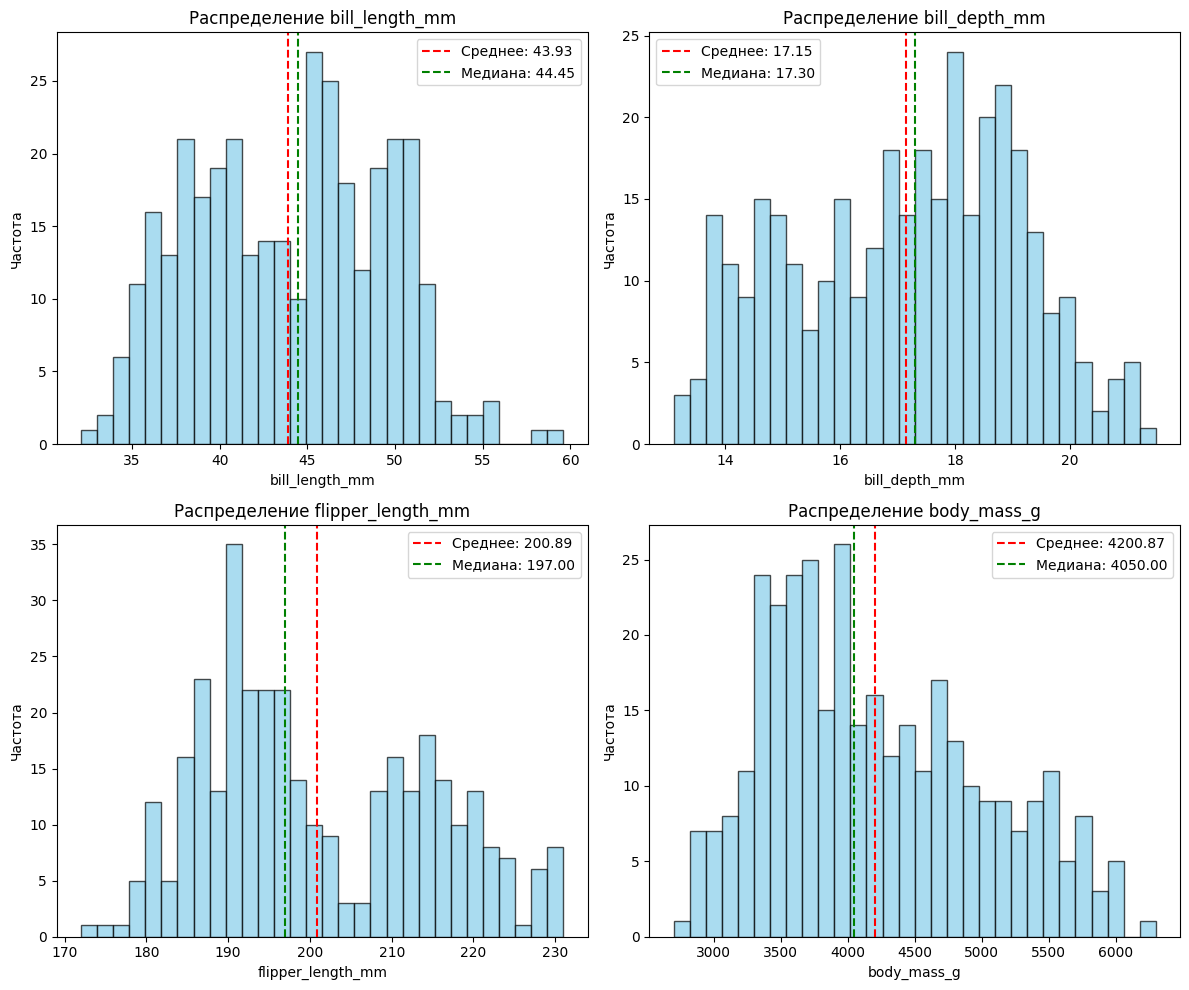

In [38]:
# Определяем числовые признаки для масштабирования (те же, что и ранее)
numerical_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Анализ диапазонов значений
print("Диапазоны значений числовых признаков:")
for col in numerical_cols:
    min_val = df_copy[col].min()
    max_val = df_copy[col].max()
    mean_val = df_copy[col].mean()
    std_val = df_copy[col].std()
    print(f"\n{col}:")
    print(f"  Диапазон: [{min_val:.2f}, {max_val:.2f}]")
    print(f"  Среднее: {mean_val:.2f}")
    print(f"  Стандартное отклонение: {std_val:.2f}")
    print(f"  Размах: {max_val - min_val:.2f}")

# Визуализация распределений до масштабирования
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df_copy[col], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[idx].axvline(df_copy[col].mean(), color='red', linestyle='--', 
                      label=f'Среднее: {df_copy[col].mean():.2f}')
    axes[idx].axvline(df_copy[col].median(), color='green', linestyle='--', 
                      label=f'Медиана: {df_copy[col].median():.2f}')
    axes[idx].set_title(f'Распределение {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Частота')
    axes[idx].legend()

plt.tight_layout()
plt.show()

In [41]:
# Создаем копию DataFrame для масштабирования
df_standard = df_copy.copy()

# Создаем StandardScaler
standard_scaler = StandardScaler()

# Применяем масштабирование к числовым признакам
df_standard[numerical_cols] = standard_scaler.fit_transform(df_standard[numerical_cols])

print("Результаты StandardScaler:")
print(f"Среднее после масштабирования: {df_standard[numerical_cols].mean().values}")
print(f"Стандартное отклонение после масштабирования: {df_standard[numerical_cols].std().values}")

print(f"\nПервые 5 строк после стандартизации:")
print(df_standard[numerical_cols].head())

Результаты StandardScaler:
Среднее после масштабирования: [-7.43591235e-16  2.89174369e-16  2.89174369e-16  8.26212483e-17]
Стандартное отклонение после масштабирования: [1.00145667 1.00145667 1.00145667 1.00145667]

Первые 5 строк после стандартизации:
   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
0       -0.887622       0.787289          -1.420541    -0.564625
1       -0.814037       0.126114          -1.063485    -0.502010
2       -0.666866       0.431272          -0.420786    -1.190773
3        0.096581       0.075255          -0.277964    -0.188936
4       -1.329133       1.092447          -0.563608    -0.940314


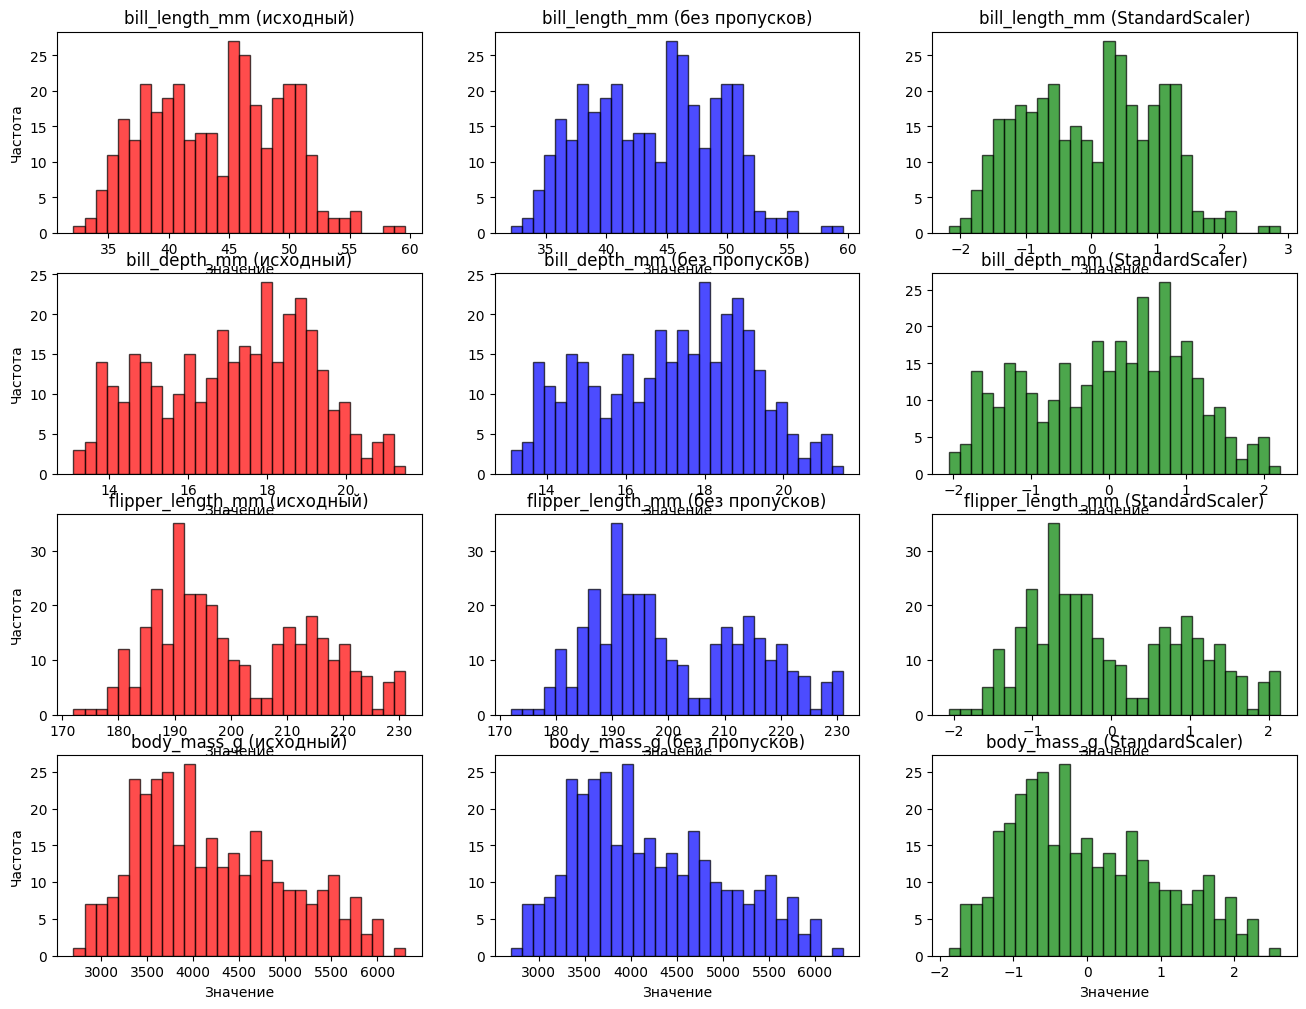

In [46]:
fig, axes = plt.subplots(4, 3, figsize=(16, 12))

for idx, col in enumerate(numerical_cols):
    # Исходные данные
    axes[idx, 0].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='red')
    axes[idx, 0].set_title(f'{col} (исходный)')
    axes[idx, 0].set_xlabel('Значение')
    axes[idx, 0].set_ylabel('Частота')

        # Исходные данные
    axes[idx, 1].hist(df_copy[col], bins=30, edgecolor='black', alpha=0.7, color='blue')
    axes[idx, 1].set_title(f'{col} (без пропусков)')
    axes[idx, 1].set_xlabel('Значение')
    
    # StandardScaler
    axes[idx, 2].hist(df_standard[col], bins=30, edgecolor='black', alpha=0.7, color='green')
    axes[idx, 2].set_title(f'{col} (StandardScaler)')
    axes[idx, 2].set_xlabel('Значение')